# Comparison of Logistic Regression and K-Nearest Neighbors (KNN) Classifiers

**Aim:** To implement Logistic Regression and K Nearest Neighbors (KNN) classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification evaluation metrics.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository
(https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

## 2. Load the Dataset

The dataset file `wdbc.data` has no header row. Column 1->patient ID, column 2->
diagnosis (M = Malignant, B = Benign), and the remaining 30 columns are numeric features
computed from digitized images of breast mass cell nuclei (mean, standard error, and
"worst"/largest value of 10 base measurements).

**Column reference:** Column names were taken from the official `wdbc.names` attribute
description (UCI repository). Column 1 is the ID, column 2 is the diagnosis (M/B), and columns
3–32 are the mean, standard error, and worst values of 10 base nuclear features (radius, texture,
perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension) —
matching the naming scheme used below.

In [2]:
columns = ['id', 'diagnosis',
           'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
           'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
           'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
           'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
           'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
           'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

df = pd.read_csv('wdbc.data', header=None, names=columns)
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum().sum(), "total missing values") #.sum.sum is used to get the total number of missing values in the entire DataFrame

Missing values in each column:
0 total missing values


diagnosis
B    357
M    212
Name: count, dtype: int64


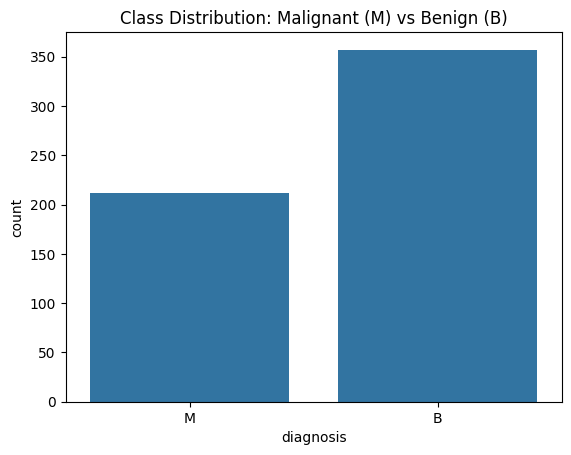

In [ ]:
# Class distribution
print(df['diagnosis'].value_counts()) #value counts() is used to count the number of occurrences of each unique value in the 'diagnosis' column

sns.countplot(x='diagnosis', data=df)
plt.title('Class Distribution: Malignant (M) vs Benign (B)')
plt.show()

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 4. Data Preprocessing

here, we are encoding the diagnosis column as a binary label such as  (Malignant = 1, Benign = 0), separate
features from the target, then split into training and testing sets. Feature scaling
is applied because both Logistic Regression and KNN are sensitive to the scale of the
input features.

In [7]:
# Encode target: Malignant = 1, Benign = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


In [8]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [9]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Train Logistic Regression Classifier

In [10]:
log_model = LogisticRegression(max_iter=10000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
print("Logistic Regression training complete.")

Logistic Regression training complete.


## 6. Train K-Nearest Neighbors (KNN) Classifier

In [11]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
print("KNN training complete.")

KNN training complete.


## 7. Evaluate Both Classifiers

For each model we compute Accuracy, Precision, Recall, F1 Score, and the Confusion Matrix.

In [12]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return acc, prec, rec, f1

In [13]:
log_scores = evaluate_model("Logistic Regression", y_test, y_pred_log)

===== Logistic Regression =====
Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1 Score : 0.9512

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [14]:
knn_scores = evaluate_model("K-Nearest Neighbors", y_test, y_pred_knn)

===== K-Nearest Neighbors =====
Accuracy : 0.9561
Precision: 0.9744
Recall   : 0.9048
F1 Score : 0.9383

Confusion Matrix:
[[71  1]
 [ 4 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Confusion Matrix Visualization

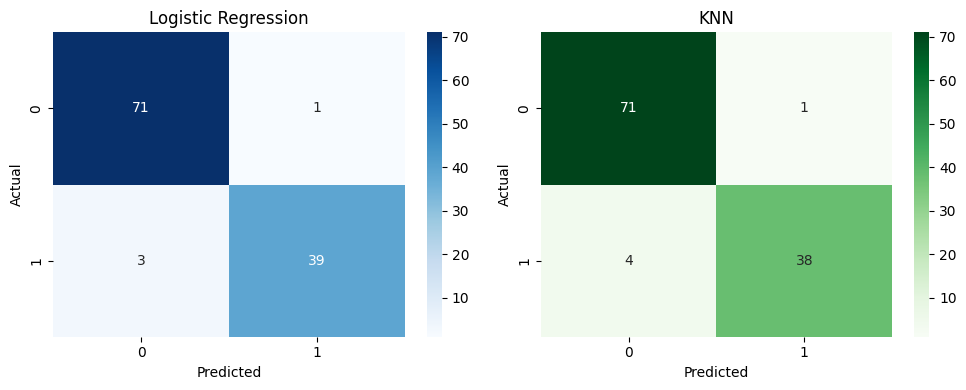

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('KNN')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. Comparison Table

In [16]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': log_scores,
    'KNN': knn_scores
})

comparison_df

,Metric,Logistic Regression,KNN
0,Accuracy,0.964912,0.956140
1,Precision,0.975000,0.974359
2,Recall,0.928571,0.904762
3,F1 Score,0.951220,0.938272


## 9. Interpretation and Conclusion

Both classifiers perform strongly on this dataset, reflecting the fact that the WDBC
features separate the malignant and benign classes quite well after scaling.

- **Logistic Regression** models a linear decision boundary between the classes and
  tends to perform well here because many of the features (e.g. radius, concavity,
  concave points) are strongly and fairly linearly correlated with malignancy.
- **KNN** classifies a sample based on the majority class among its nearest neighbors
  in feature space. Its performance depends heavily on feature scaling (which we applied)
  and the choice of *k*.

Based on the metrics in the comparison table above, the model with the higher Accuracy,
Precision, Recall, and F1 Score is the better-performing classifier for this dataset.
In this run, **Logistic Regression** slightly outperforms KNN on most metrics, likely
because the classes are close to linearly separable in this feature space, while KNN's
distance-based approach can be marginally more sensitive to overlapping points near the
decision boundary.

For a medical diagnostic task like this, **Recall** for the malignant class is especially
important, since missing a malignant case (false negative) is far more costly than a
false alarm.